In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
import joblib                                       # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf                             # 텐서플로우 lib


from tensorflow.keras import layers, models

# 케라스의 모델 저장 및 로드 기능을 사용하기 위한 필요 모듈
from tensorflow.keras import Sequential                   
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# 그래프 한글 폰트 설정
from matplotlib import font_manager, rc
font_path = "/mnt/c/Windows/Fonts/malgun.ttf"

# Windows 폰트를 현재 Matplotlib에 등록
font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False


np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# 1.데이터 가져오기
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# # CNN 입력 형태에 맞게 채널 차원을 reshape
y_train = y_train.reshape(-1)     # shape(30000, 1) --> (30000)
y_test = y_test.reshape(-1)       # shape(10000, 1) --> (10000)

class_names = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]


In [4]:
y_train.shape

(50000,)

In [5]:
X_train.shape

(50000, 32, 32, 3)

In [6]:
# 2. 스케일링(데이터 정규화)
X_train = X_train / 255.0
X_test = X_test / 255.0

In [7]:
# 3. 모델 정의 <-- cnn layer 3개층 + 출력층으로 구성
model = Sequential()

# 모델 신경망 생성(합성곱 층)
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))

# 풀링 층 추가
model.add(MaxPooling2D((2,2)))

# 두번째 층 추가
model.add(Conv2D(64, (3,3), activation='relu'))

# 두번째 풀링 층 추가
model.add(MaxPooling2D((2,2)))

# 1차원 벡터로 펼침
model.add(Flatten())

# 완전 연결층 추가
model.add(Dense(128, activation='relu'))

# 드롭아웃 추가
model.add(Dropout(0.3))

# 출력층 추가
model.add(Dense(10, activation='softmax'))

/home/pc/anaconda3/envs/ai/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1787294497.805716  138721 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787294497.826756  138721 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [8]:
# 4. 모델 컴파일 설정
model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

# 학습 조기 종료 설정
early_stop = EarlyStopping(
  monitor='val_loss',
  patience=5,
  restore_best_weights=True
)

In [ ]:
# 5. 모델 학습
history = model.fit(
  X_train,               # 입력데이터 X
  y_train,                      # 정답데이터 y
  validation_split=0.2,           # 검증 20%
  epochs=20,                   # 전체 학습 수 20번
  batch_size=64,                # 한번에 도는 학습 1회 사이클 64번
  callbacks=[early_stop]        # 조기종료 콜백 정의
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4067 - loss: 1.6305 - val_accuracy: 0.5267 - val_loss: 1.3290
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5373 - loss: 1.3009 - val_accuracy: 0.5880 - val_loss: 1.1672
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5889 - loss: 1.1594 - val_accuracy: 0.6269 - val_loss: 1.0735
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6287 - loss: 1.0543 - val_accuracy: 0.6445 - val_loss: 1.0193
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6555 - loss: 0.9896 - val_accuracy: 0.6580 - val_loss: 0.9854
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6671 - loss: 0.9339 - val_accuracy: 0.6744 - val_loss: 0.9461
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6919 - loss: 0.8758 - val_accuracy: 0.6781 - val_loss: 0.9322
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7063 - loss: 0.8291 - val_accuracy: 0.

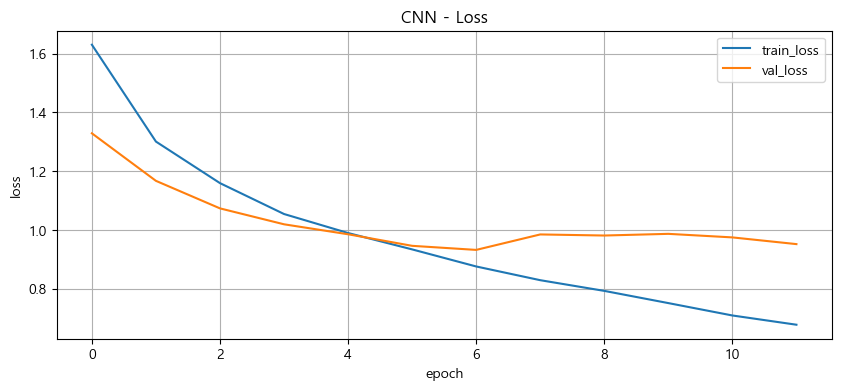

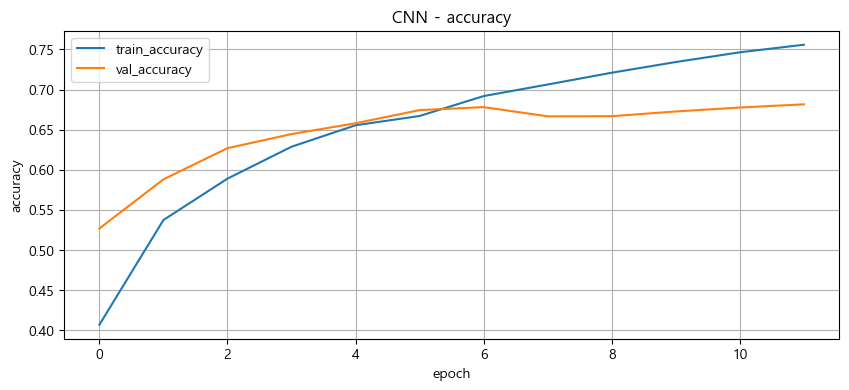

In [12]:
# 6. 결과 시각화

# 학습 손실 그래프
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('CNN - Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)

plt.show()


# 학습 정확도 그래프
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('CNN - accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [13]:
# 테스트 데이터 예측 확률 계산
y_prob = model.predict(X_test)

# 최종 예측 클래스 계산
y_pred = np.argmax(y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [14]:
new_images = X_test[:5]

# 신규 이미지 예측
new_prob = model.predict(new_images)

# 최종 클래스 예측값 계산
new_pred = np.argmax(new_prob, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


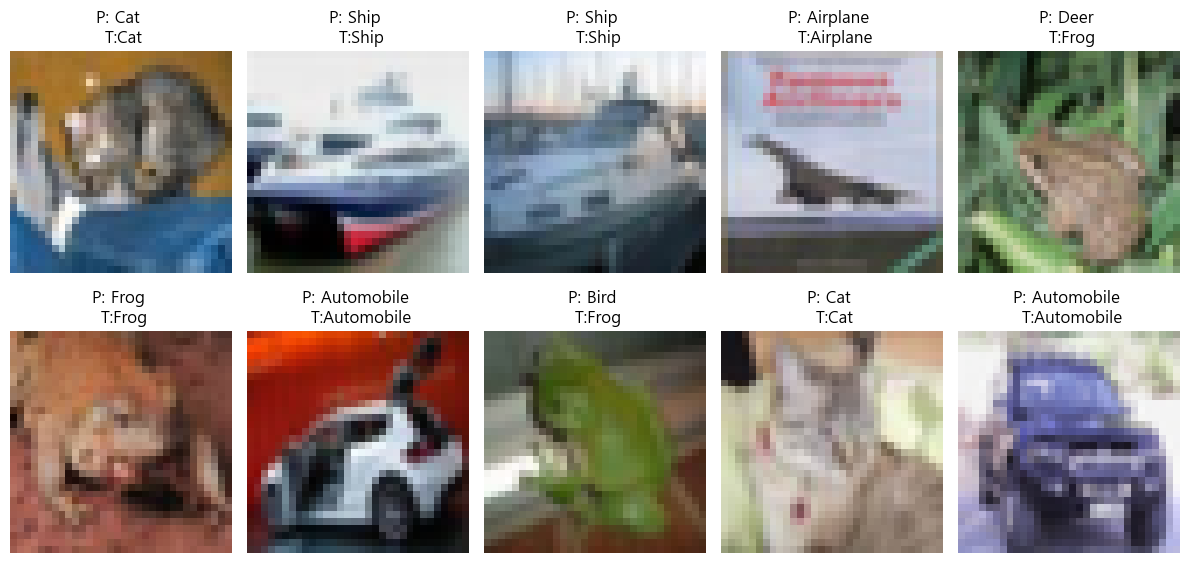

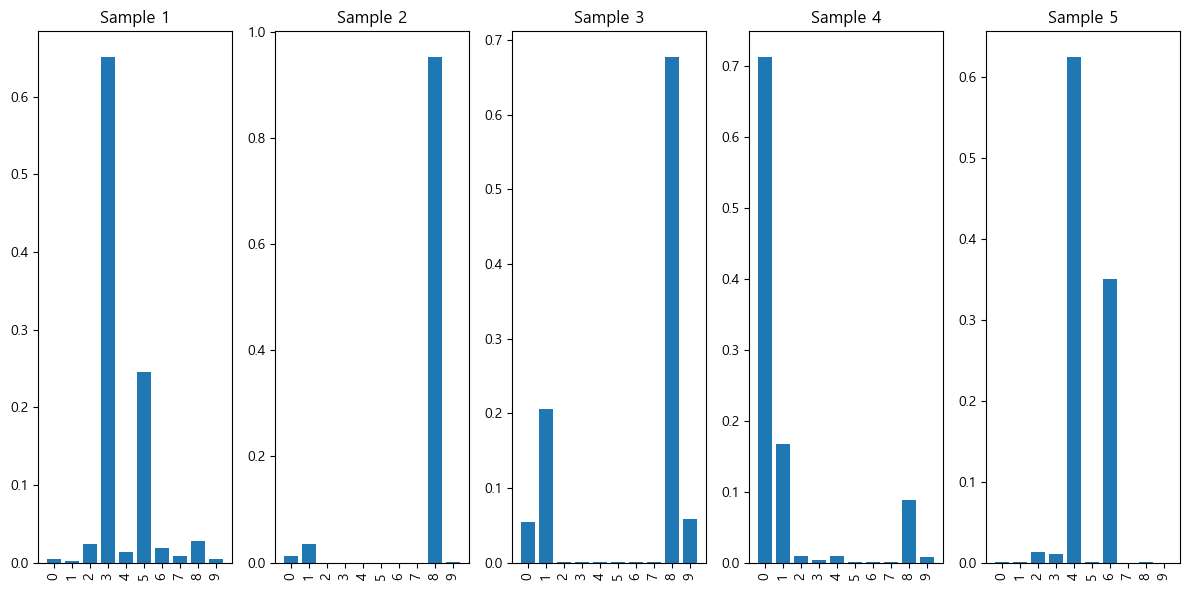

In [17]:
# 테스트 이미지(10개)와 예측 결과 시각화
plt.figure(figsize=(12,6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i])
    plt.title(f"P: {class_names[y_pred[i]]} \n T:{class_names[y_test[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# 신규 이미지 5개에 대한 확률 분포 시각화
plt.figure(figsize=(12,6))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.bar(range(10), new_prob[i])
    plt.title(f"Sample {i+1}")
    plt.xticks(range(10), rotation=90)

plt.tight_layout()
plt.show()